---
Author: The Tuan Trinh \
Date: 2026-05-25
---

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: posix
System: Linux
Release: 4.18.0-348.12.2.el8_5.x86_64
Machine: x86_64
Processor: x86_64
Platform: Linux-4.18.0-348.12.2.el8_5.x86_64-x86_64-with-glibc2.28

Environment Variables (sample):
CONDA_SHLVL = 2
LD_LIBRARY_PATH = /usr/local/cuda/lib64:/usr/local/cuda/lib64:
CONDA_EXE = /work/tuan.tt19010226/miniconda/bin/conda
SSH_CONNECTION = 10.4.98.97 55721 10.20.8.11 22
CONDA_PREFIX = /work/tuan.tt19010226/conda/envs/RadarLM
XDG_SESSION_ID = 73826
USER = tuan.tt19010226
PWD = /home/tuan.tt19010226
HOME = /home/tuan.tt19010226
CONDA_PYTHON_EXE = /work/tuan.tt19010226/miniconda/bin/python
SSH_CLIENT = 10.4.98.97 55721 22
MESA_LOADER_DRIVER_OVERRIDE = llvmpipeexport
CONDA_PROMPT_MODIFIER = (RadarLM) 
VSCODE_CLI_REQUIRE_TOKEN = ff966dd2-9842-4540-a110-3a8647ed17e8
SHELL = /bin/bash


In [2]:
platform.python_version()

'3.10.19'

# Lab 5 - Convolution

In [3]:
import numpy as np


class Conv2D:
    def __init__(self, kernel,
                       stride=1, 
                       padding=0):
        """
        kernel       : 2D numpy array
        stride       : step size
        padding      : zero padding
        """
        self.kernel = kernel
        self.stride = stride
        self.padding = padding
        # self.flip_kernel = flip_kernel

    def forward(self, image):
        kernel = self.kernel
        # # Flip kernel for true convolution
        # if self.flip_kernel:
        #     kernel = np.flipud(np.fliplr(kernel))
        H, W = image.shape
        kH, kW = kernel.shape
        padded_image = np.pad(
            image,
            ((self.padding, self.padding),
             (self.padding, self.padding)),
            mode='constant'
        )
        out_H = (H + 2 * self.padding - kH) // self.stride + 1
        out_W = (W + 2 * self.padding - kW) // self.stride + 1
        output = np.zeros((out_H, out_W))
        # Convolution operation
        for y in range(out_H):
            for x in range(out_W):
                region = padded_image[
                    y*self.stride:y*self.stride+kH,
                    x*self.stride:x*self.stride+kW
                ]
                output[y, x] = np.sum(region * kernel)

        return output

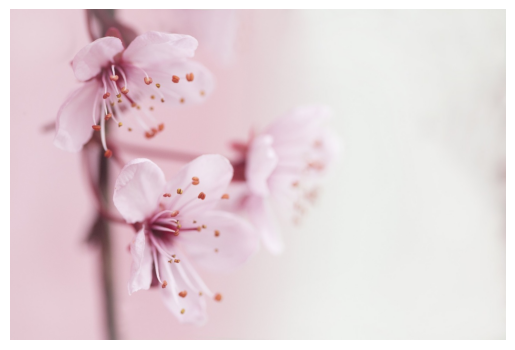

In [4]:
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import io

url = "https://64.media.tumblr.com/4e4be46ca4a62f770797c31f4dd91088/tumblr_pn8bq6ZvGc1tawn8uo1_1280.jpg"
resp = urllib.request.urlopen(url)
img = np.asarray(bytearray(resp.read()), dtype=np.uint8)
img_pil = Image.open(io.BytesIO(img))
plt.imshow(img_pil)
plt.axis("off")
plt.show()

## From scratch

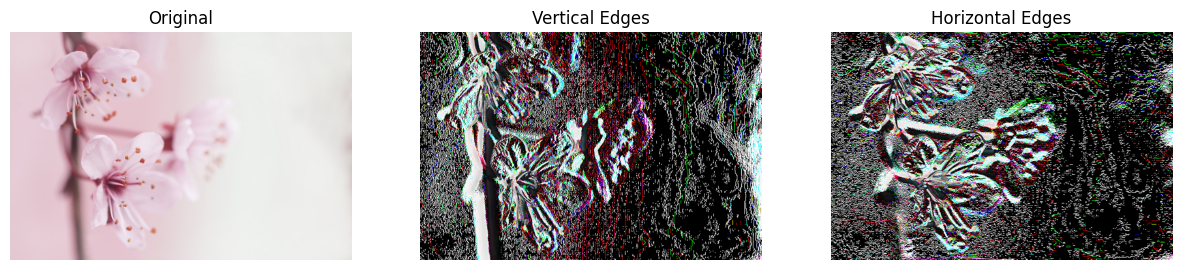

In [5]:
img_np = np.array(img_pil, dtype=np.float32)

kernel_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

kernel_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float32)

conv_x = Conv2D(kernel_x, padding=0)
conv_y = Conv2D(kernel_y, padding=0)

edge_x_channels = []
edge_y_channels = []

for c in range(3):
    channel = img_np[:, :, c]
    edge_x = conv_x.forward(channel)
    edge_y = conv_y.forward(channel)
    edge_x_channels.append(edge_x)
    edge_y_channels.append(edge_y)

edge_x_rgb = np.stack(edge_x_channels, axis=2)
edge_y_rgb = np.stack(edge_y_channels, axis=2)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_np.astype(np.uint8))
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(edge_x_rgb.astype(np.uint8))
plt.title("Vertical Edges")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(edge_y_rgb.astype(np.uint8))
plt.title("Horizontal Edges")
plt.axis("off")
plt.show()

# cv2 library

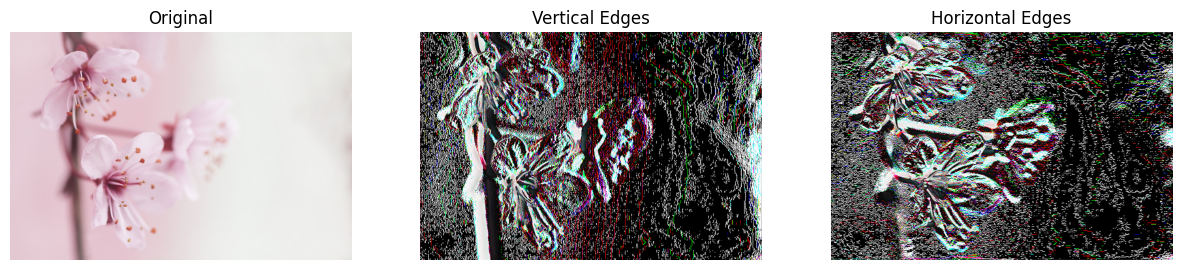

In [6]:
import cv2

edge_x_ = cv2.filter2D(
    src=img_np,
    ddepth=-1,
    kernel=kernel_x,
    borderType=cv2.BORDER_CONSTANT
)
edge_y_ = cv2.filter2D(
    src=img_np,
    ddepth=-1,
    kernel=kernel_y,
    borderType=cv2.BORDER_CONSTANT
)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img_np.astype(np.uint8))
plt.title("Original")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(edge_x_.astype(np.uint8))
plt.title("Vertical Edges")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(edge_y_.astype(np.uint8))
plt.title("Horizontal Edges")
plt.axis("off")
plt.show()